In [1]:
import os
import pickle
import requests
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ----------------------- Настройки и константы -----------------------
SEQ_LENGTH = 20
TRAIN_TEST_RATIO = 0.8
RSI_PERIOD = 14
SMA_WINDOW = 14
SEED = 42
TICKER = "GAZP"

torch.manual_seed(SEED)
np.random.seed(SEED)

In [2]:
def fetch_moex_eod_data(security, engine, market, board, start_date, end_date):
    base_url = f"https://iss.moex.com/iss/history/engines/{engine}/markets/{market}/boards/{board}/securities/{security}.json"
    all_data = []
    columns = None
    offset = 0
    limit = 100
    while True:
        params = {"from": start_date, "till": end_date, "start": offset}
        response = requests.get(base_url, params=params)
        if response.status_code != 200:
            print(f"Ошибка: HTTP {response.status_code}")
            break
        data = response.json()
        try:
            if columns is None:
                columns = data["history"]["columns"]
            page_data = data["history"]["data"]
            if not page_data:
                break
            all_data.extend(page_data)
            if len(page_data) < limit:
                break
            offset += limit
        except KeyError:
            print("Ошибка формата данных.")
            break
    if all_data and columns:
        return pd.DataFrame(all_data, columns=columns)
    else:
        return None

def compute_rsi(series: pd.Series, period: int = RSI_PERIOD) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_sma(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    return series.rolling(window=window).mean()

def compute_log_returns(series: pd.Series, window: int = 1) -> pd.Series:
    return np.log(series).diff(window)

def compute_volatility(series: pd.Series, window: int = SMA_WINDOW) -> pd.Series:
    returns = compute_log_returns(series)
    return returns.rolling(window=window).std()

def compute_macd(series: pd.Series, fast_period=12, slow_period=26, signal_period=9):
    ema_fast = series.ewm(span=fast_period, adjust=False).mean()
    ema_slow = series.ewm(span=slow_period, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
    macd_hist = macd_line - signal_line
    return macd_line, signal_line, macd_hist

def compute_bollinger_bands(series: pd.Series, window=20, num_std=2):
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper_band = sma + (std * num_std)
    lower_band = sma - (std * num_std)
    return upper_band, lower_band, sma

def compute_atr(df: pd.DataFrame, ticker: str, window: int = 14) -> pd.Series:
    high_col = f"HIGH_{ticker}"
    low_col = f"LOW_{ticker}"
    close_col = f"CLOSE_{ticker}"
    high_low = df[high_col] - df[low_col]
    high_prev_close = np.abs(df[high_col] - df[close_col].shift(1))
    low_prev_close = np.abs(df[low_col] - df[close_col].shift(1))
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    atr = true_range.rolling(window=window).mean()
    return atr


# Подготовка данных: загрузка, объединение датасетов и создание последовательностей


In [3]:
def load_raw_data(ticker=TICKER, cache_file="raw_moex_data.pkl"):
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            merged_df = pickle.load(f)
        print("Данные загружены из кэша.")
        return merged_df

    start_date = "2013-01-01"
    end_date = datetime.today().strftime("%Y-%m-%d")
    
    print(f"Загружаем данные {ticker} с MOEX...")
    ticker_df = fetch_moex_eod_data(ticker, "stock", "shares", "TQBR", start_date, end_date)
    print("Загружаем IMOEX...")
    imoex_df = fetch_moex_eod_data("IMOEX", "stock", "index", "SNDX", start_date, end_date)
    print("Загружаем USD/RUB...")
    usd_df = fetch_moex_eod_data("USD000UTSTOM", "currency", "selt", "CETS", start_date, end_date)
    
    if ticker_df is None or imoex_df is None or usd_df is None:
        raise ValueError("Ошибка при загрузке датасетов.")
    
    for df in [ticker_df, imoex_df, usd_df]:
        df["TRADEDATE"] = pd.to_datetime(df["TRADEDATE"])
        df.sort_values("TRADEDATE", inplace=True)
        df.reset_index(drop=True, inplace=True)
    
    ticker_df.rename(columns={
        "CLOSE": f"CLOSE_{ticker}",
        "OPEN": f"OPEN_{ticker}",
        "HIGH": f"HIGH_{ticker}",
        "LOW": f"LOW_{ticker}",
        "VOLUME": f"VOL_{ticker}"
    }, inplace=True)
    imoex_df.rename(columns={"CLOSE": "CLOSE_IMOEX"}, inplace=True)
    usd_df.rename(columns={"CLOSE": "CLOSE_USD"}, inplace=True)
    
    ticker_df = ticker_df[["TRADEDATE", f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}"]]
    imoex_df = imoex_df[["TRADEDATE", "CLOSE_IMOEX"]]
    usd_df = usd_df[["TRADEDATE", "CLOSE_USD"]]
    
    merged_df = ticker_df.merge(imoex_df, on="TRADEDATE", how="outer") \
                         .merge(usd_df, on="TRADEDATE", how="outer")
    merged_df.sort_values("TRADEDATE", inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    merged_df.dropna(subset=[f"CLOSE_{ticker}", "CLOSE_IMOEX", "CLOSE_USD"], inplace=True)
    merged_df.reset_index(drop=True, inplace=True)
    
    with open(cache_file, "wb") as f:
        pickle.dump(merged_df, f)
    print("Данные сохранены в кэш.")
    return merged_df

def create_sequences(X, y, seq_length=SEQ_LENGTH):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

def prepare_data(raw_df: pd.DataFrame, ticker=TICKER):
    df = raw_df.copy()
    close_col = f"CLOSE_{ticker}"
    
    # Вычисляем технические индикаторы
    df['LOG_RETURNS'] = compute_log_returns(df[close_col])
    df['RSI'] = compute_rsi(df[close_col])
    df['SMA'] = compute_sma(df[close_col])
    df['VOLATILITY'] = compute_volatility(df[close_col])
    df['SMA_RETURNS'] = compute_log_returns(df['SMA'])
    
    macd_line, macd_signal, macd_hist = compute_macd(df[close_col])
    df['MACD_LINE'] = macd_line
    df['MACD_SIGNAL'] = macd_signal
    df['MACD_HIST'] = macd_hist

    bb_upper, bb_lower, bb_middle = compute_bollinger_bands(df[close_col])
    df['BB_UPPER'] = bb_upper
    df['BB_LOWER'] = bb_lower
    df['BB_MIDDLE'] = bb_middle

    df['ATR'] = compute_atr(df, ticker=ticker, window=SMA_WINDOW)
    
    df = df.dropna().reset_index(drop=True)
    
    split_idx = int(len(df) * TRAIN_TEST_RATIO)
    train_df = df.iloc[:split_idx].copy()
    test_df  = df.iloc[split_idx:].copy()
    
    features = [
        f"OPEN_{ticker}", f"HIGH_{ticker}", f"LOW_{ticker}", f"CLOSE_{ticker}", f"VOL_{ticker}",
        "CLOSE_IMOEX", "CLOSE_USD",
        "RSI", "SMA_RETURNS", "VOLATILITY", "LOG_RETURNS",
        "MACD_LINE", "MACD_SIGNAL", "MACD_HIST",
        "BB_UPPER", "BB_LOWER", "BB_MIDDLE",
        "ATR"
    ]
    target = f"CLOSE_{ticker}"
    
    X_train = train_df[features].values.astype(float)
    X_test  = test_df[features].values.astype(float)
    y_train = train_df[[target]].values.astype(float)
    y_test  = test_df[[target]].values.astype(float)
    
    scaler_X = RobustScaler()
    scaler_y = RobustScaler()
    scaler_X.fit(X_train)
    scaler_y.fit(y_train)
    
    X_train_scaled = scaler_X.transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)
    y_train_scaled = scaler_y.transform(y_train)
    y_test_scaled  = scaler_y.transform(y_test)
    
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled)
    X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled)
    
    train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32),
                                  torch.tensor(y_train_seq, dtype=torch.float32))
    test_dataset = TensorDataset(torch.tensor(X_test_seq, dtype=torch.float32),
                                 torch.tensor(y_test_seq, dtype=torch.float32))
    
    return train_dataset, test_dataset, scaler_X, scaler_y, len(features)


# Определяем архитектуру TCN и вспомогательные слои

In [4]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        
        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.dropout2 = nn.Dropout(dropout)
        
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu(self.bn1(out))
        out = self.dropout1(out)
        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu(self.bn2(out))
        out = self.dropout2(out)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCN(nn.Module):
    def __init__(self, num_inputs, num_channels, kernel_size=2, dropout=0.2):
        super(TCN, self).__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_channels = num_inputs if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers += [TemporalBlock(in_channels, out_channels, kernel_size, stride=1,
                                       dilation=dilation_size,
                                       padding=(kernel_size-1)*dilation_size,
                                       dropout=dropout)]
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

class TCNModel(nn.Module):
    def __init__(self, num_features, num_channels, kernel_size=2, dropout=0.2, fc_units=32):
        super(TCNModel, self).__init__()
        self.tcn = TCN(num_inputs=num_features, num_channels=num_channels, kernel_size=kernel_size, dropout=dropout)
        self.fc = nn.Linear(num_channels[-1], fc_units)
        self.out = nn.Linear(fc_units, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # x: (batch, seq_length, num_features)
        x = x.permute(0, 2, 1)         # (batch, num_features, seq_length)
        tcn_out = self.tcn(x)          # (batch, last_channel, seq_length_after_chomp)
        last_out = tcn_out[:, :, -1]   # Берём выход последнего временного шага
        x = self.relu(self.fc(last_out))
        return self.out(x)


# Обучение модели с фиксированными гиперпараметрами

Данные загружены из кэша.
Epoch 1/40 | Train Loss: 0.0684 | Val Loss: 0.0060
Epoch 2/40 | Train Loss: 0.0266 | Val Loss: 0.0031
Epoch 3/40 | Train Loss: 0.0112 | Val Loss: 0.0041
Epoch 4/40 | Train Loss: 0.0061 | Val Loss: 0.0060
Epoch 5/40 | Train Loss: 0.0051 | Val Loss: 0.0124
Epoch 6/40 | Train Loss: 0.0049 | Val Loss: 0.0019
Epoch 7/40 | Train Loss: 0.0055 | Val Loss: 0.0020
Epoch 8/40 | Train Loss: 0.0049 | Val Loss: 0.0022
Epoch 9/40 | Train Loss: 0.0051 | Val Loss: 0.0019
Epoch 10/40 | Train Loss: 0.0038 | Val Loss: 0.0021
Epoch 11/40 | Train Loss: 0.0047 | Val Loss: 0.0021
Epoch 12/40 | Train Loss: 0.0036 | Val Loss: 0.0021
Epoch 13/40 | Train Loss: 0.0033 | Val Loss: 0.0023
Epoch 14/40 | Train Loss: 0.0038 | Val Loss: 0.0041
Epoch 15/40 | Train Loss: 0.0038 | Val Loss: 0.0049
Epoch 16/40 | Train Loss: 0.0029 | Val Loss: 0.0025
Epoch 17/40 | Train Loss: 0.0023 | Val Loss: 0.0018
Epoch 18/40 | Train Loss: 0.0023 | Val Loss: 0.0013
Epoch 19/40 | Train Loss: 0.0024 | Val Loss: 0.

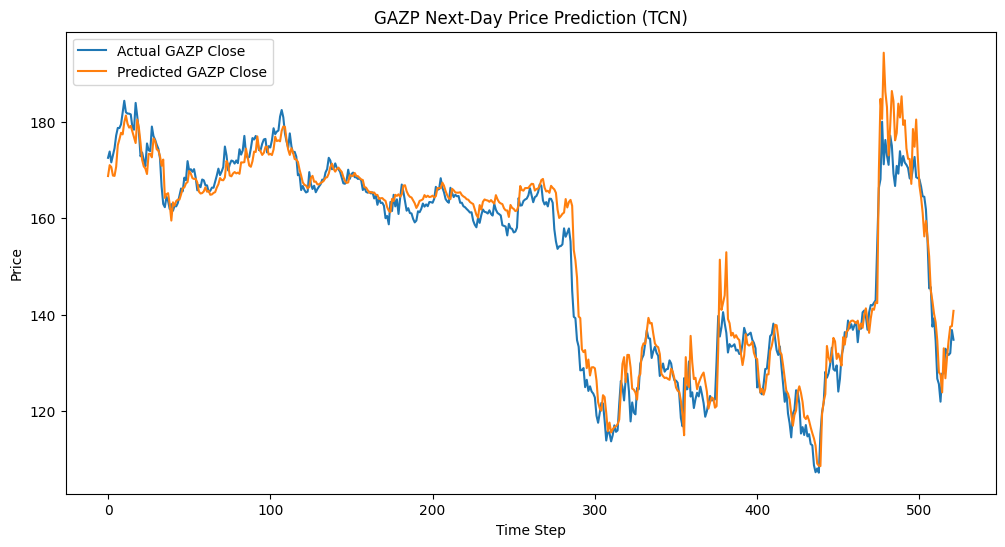

In [9]:
n_levels = 4
base_channels = 64
num_channels = [base_channels * (2 ** i) for i in range(n_levels)]  # [32, 64]
kernel_size = 5
dropout = 0.28401188180992987
fc_units = 30
lr = 0.0024237251391464117
weight_decay = 2.7326194610424024e-05

# Настройки обучения
n_epochs = 40
batch_size = 16
patience = 15

# Подготовка данных
raw_df = load_raw_data(ticker=TICKER)
train_dataset, test_dataset, scaler_X, scaler_y, num_features = prepare_data(raw_df, ticker=TICKER)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Инициализируем модель и оптимизатор
model = TCNModel(num_features=num_features, num_channels=num_channels,
                 kernel_size=kernel_size, dropout=dropout, fc_units=fc_units)
model.to(device)

criterion = nn.HuberLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

for epoch in range(n_epochs):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())
    avg_train_loss = np.mean(train_losses)
    
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_losses.append(loss.item())
    avg_val_loss = np.mean(val_losses)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    if device.type == 'cuda':
        torch.cuda.empty_cache()

if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Оценка финальной модели
model.eval()
preds_list = []
actual_list = []
test_losses = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        test_losses.append(loss.item())
        preds_list.append(outputs.cpu().numpy())
        actual_list.append(y_batch.cpu().numpy())
avg_test_loss = np.mean(test_losses)
print("Final Test Loss (Huber):", avg_test_loss)

preds = np.concatenate(preds_list, axis=0)
actuals = np.concatenate(actual_list, axis=0)
preds_inv = scaler_y.inverse_transform(preds)
actuals_inv = scaler_y.inverse_transform(actuals)

mse_orig = mean_squared_error(actuals_inv, preds_inv)
rmse_orig = np.sqrt(mse_orig)
mae_orig = mean_absolute_error(actuals_inv, preds_inv)
mape_orig = np.mean(np.abs((actuals_inv - preds_inv) / actuals_inv)) * 100

print(f"\nМетрики для {TICKER}:")
print(f"MSE: {mse_orig:.3f}")
print(f"RMSE: {rmse_orig:.3f}")
print(f"MAE: {mae_orig:.3f}")
print(f"MAPE: {mape_orig:.2f}%")

plt.figure(figsize=(12,6))
plt.plot(actuals_inv.flatten(), label=f"Actual {TICKER} Close")
plt.plot(preds_inv.flatten(), label=f"Predicted {TICKER} Close")
plt.title(f"{TICKER} Next-Day Price Prediction (TCN)")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.show()


In [10]:
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "GAZP_model.pth")
scaler_X_path = os.path.join("models", "GAZP_scaler_X.pkl")
scaler_y_path = os.path.join("models", "GAZP_scaler_y.pkl")
    
torch.save(model.state_dict(), model_path)
with open(scaler_X_path, "wb") as f:
    pickle.dump(scaler_X, f)
    with open(scaler_y_path, "wb") as f:
        pickle.dump(scaler_y, f)
        print(f"\nМодель и скейлеры сохранены в папке 'models'.")


Модель и скейлеры сохранены в папке 'models'.
